In [ ]:
#================================
# Task 6: House Price Prediction
#================================

In [ ]:
#=====================
# linear Regression
#====================

MAE: 7671338.42858785
RMSE: 25442231.710000966


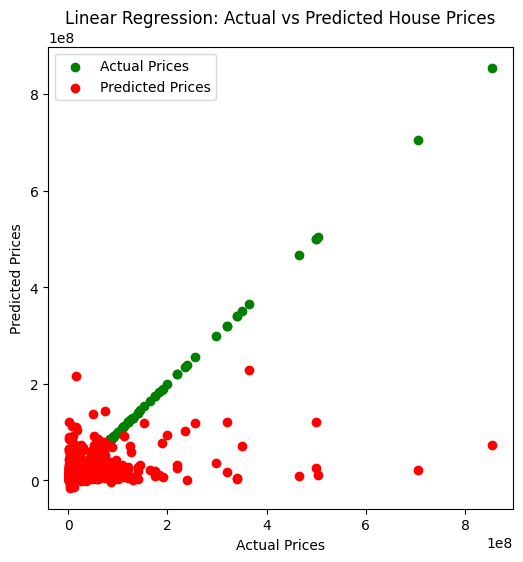

Predicted House Price: 24615790.150393058


In [ ]:
# ===========================
# IMPORTS
# ===========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ===========================
# LOAD DATA
# ===========================
df = pd.read_csv("csvdata.csv")

# ===========================
# FEATURES & TARGET
# ===========================
X = df[["Area", "No. of Bedrooms", "Location"]]
y = df["Price"]

# ===========================
# TRAIN-TEST SPLIT
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_cols = ["Location"]

# ===========================
# ONE-HOT ENCODING
# ===========================
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# save columns for unseen data
train_columns = X_train.columns

# ===========================
# FEATURE SCALING (IMPORTANT FOR LINEAR REGRESSION)
# ===========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===========================
# MODEL (Linear Regression)
# ===========================
model = LinearRegression()
model.fit(X_train, y_train)

# ===========================
# PREDICTIONS
# ===========================
y_pred = model.predict(X_test)

# ===========================
# EVALUATION
# ===========================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# ===========================
# VISUALIZATION
# ===========================
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test, color="green", label="Actual Prices")
plt.scatter(y_test, y_pred, color="red", label="Predicted Prices")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted House Prices")
plt.legend()
plt.show()

# ===========================
# UNSEEN DATA
# ===========================
new_data = pd.DataFrame([{
    "Area": 3340,
    "No. of Bedrooms": 4,
    "Location": "JP Nagar Phase 1"
}])

new_data = pd.get_dummies(new_data, columns=categorical_cols, drop_first=True)
new_data = new_data.reindex(columns=train_columns, fill_value=0)

# scaling (IMPORTANT)
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Predicted House Price:", prediction[0])

In [ ]:
#====================
# Grdient Boosting
#====================

MAE: 8277457.714276798
RMSE: 25541383.073473796


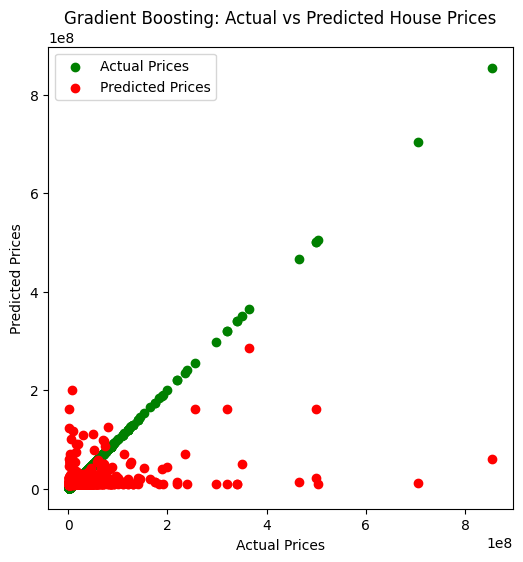

Predicted House Price: 20984346.968616452


In [ ]:

# ===========================
# IMPORTS
# ===========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ===========================
# LOAD DATA
# ===========================
df = pd.read_csv("csvdata.csv")

# ===========================
# FEATURES & TARGET
# ===========================
X = df[["Area", "No. of Bedrooms", "Location"]]
y = df["Price"]

# ===========================
# TRAIN-TEST SPLIT
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_cols = ["Location"]

# ===========================
# ONE-HOT ENCODING
# ===========================
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# save columns for unseen data
train_columns = X_train.columns

# ===========================
# MODEL TRAINING
# ===========================
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# ===========================
# PREDICTIONS
# ===========================
y_pred = model.predict(X_test)

# ===========================
# EVALUATION
# ===========================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# ===========================
# VISUALIZATION
# ===========================
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test, color="green", label="Actual Prices")
plt.scatter(y_test, y_pred, color="red", label="Predicted Prices")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Gradient Boosting: Actual vs Predicted House Prices")
plt.legend()
plt.show()

# ===========================
# UNSEEN DATA
# ===========================
new_data = pd.DataFrame([{
    "Area": 3340,
    "No. of Bedrooms": 4,
    "Location": "JP Nagar Phase 1"
}])

new_data = pd.get_dummies(new_data, columns=categorical_cols, drop_first=True)
new_data = new_data.reindex(columns=train_columns, fill_value=0)

prediction = model.predict(new_data)

print("Predicted House Price:", prediction[0])